<a href="https://colab.research.google.com/github/hyperdbio/Android-inject/blob/master/ex04)_%ED%8C%A8%EC%85%98%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%8B%A4%EC%A4%91%EB%B6%84%EB%A5%98_%EC%8B%A4%EC%8A%B5(MLP).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 오늘의 목표
- 패션데이터를 가지고 활성화 함수, 최적화 함수를 변화시켜가면서 결과를 확인하는 실습을 진행해보기
- 모델 체크포인트를 설정하여 조기 학습을 중단하는 얼리스탑을 사용해보기


In [ ]:
# 데이터 불러오기
# sklearn에서만 데이터를 제공하는 것이 아닌 tenserflow에서도 데이터 셋을 제공해준다.
# tensorflow에 제공하는 패션데이터를 불러와서 활용하기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

In [ ]:
# 데이터 로드
data = fashion_mnist.load_data()
data

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [ ]:
# 데이터 분할
X_train = data[0][0]
y_train = data[0][1]
X_test = data[1][0]
y_test = data[1][1]

In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [ ]:
X_train[0].shape

(28, 28)

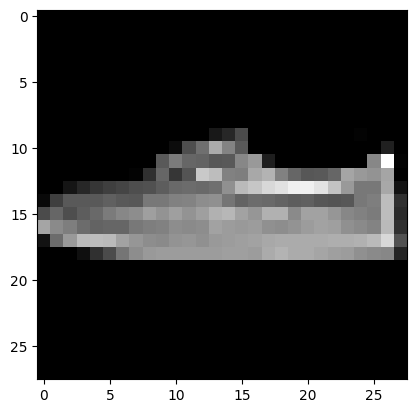

In [ ]:
# 이미지 출력
plt.imshow(X_train[40000], cmap='gray')

In [ ]:
# MLP를 사용하기 때문에 정답데이터
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

### 정답데이터 분류
- 0 : 티셔츠
- 1 : 트라우저(바지)
- 2 : 단추가 없는 스웨터
- 3 : 드레스
- 4 : 코트
- 5 : 샌들
- 6 : 셔츠
- 7 : 스니커즈
- 8 : 가방
- 9 : 앵클 부츠

### 신경망 구축
- 데이터 전처리
- MLP 구성

### MLP 사용시 주의점
- 이미지는 2차원(흑백) 또는 3차원(컬러)의 형태를 가짐
- MLP는 1차원의 데이터만 학습이 가능
- 이미지 데이터의 차원을 1차원으로 변경하여 학습을 진행하기!

### 이미지 전처리
- MLP를 사용하기 위해 이미지의 차원을 1차원으로 변경하기 위해 reshape를 이용하여 데이터의 형태를 변형


In [ ]:
# (28,28) -> 1차원인 (28*28,) 변경하기
X_train_rs = X_train.reshape(60000,28*28)
X_test_rs = X_test.reshape(10000,28*28)
# X_train.reshape.(60000,-1)
# X_test.reshape(10000,-1)

In [ ]:
X_train_rs.shape, X_test_rs.shape

((60000, 784), (10000, 784))

### 정답데이터 변경
- MLP를 사용하려면 정답데이터를 원핫인코딩 진행하기


In [ ]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

In [ ]:
# 원핫 인코딩 진행
y_train_one_hot = pd.get_dummies(y_train)
y_test_one_hot = pd.get_dummies(y_test)

In [ ]:
y_train_one_hot.head()

,0,1,2,3,4,5,6,7,8,9
0,False,False,False,False,False,False,False,False,False,True
1,True,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False


### 활성화 함수, 최적화 함수 별 성능을 비교해보기
1. 활성화함수 : sigmoid, 최적화함수 SGD
2. 활성화함수 : relu, 최적화함수 SGD
3. 활성화함수 : relu, 최적화함수 Adam
- 함수별 신경망을 설계하여 결과를 비교하기!

In [ ]:
# 각 함수를 사용하기 위해 도구 불러오기
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD, Adam

In [ ]:
# 모델 생성을 위한 함수를 정의
def get_model(acti, opti):
  # 뼈대 구축
    model = Sequential()
    # 입력층
    model.add(Flatten(input_shape = (28,28)))
    # Flatten -> 입력층으로 부터 입력받은 데이터를 1차원으로 변경해서 사용하는 기능

    # 중간층
    model.add(Dense(200, activation=acti))
    model.add(Dense(100, activation=acti))
    model.add(Dense(50, activation=acti))

    # 출력층
    model.add(Dense(10,activation='softmax'))

    # 모델 성능을 위한 설정
    model.compile(loss = 'categorical_crossentropy',
                  optimizer = opti,
                  metrics=['accuracy'])

    return model

In [ ]:
# 학습하는 함수를 정의
def fit_model(model):
  h = model.fit(X_train, y_train_one_hot,
                validation_split = 0.3,
                epochs = 30,
                batch_size = 64)
  return h


In [ ]:
# 첫번째 모델 설계
# acti : sigmoid / opti : SGD
model = get_model('sigmoid', SGD(learning_rate=0.01))
h1 = fit_model(model)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2553 - loss: 2.2988 - val_accuracy: 0.4866 - val_loss: 2.0795
Epoch 2/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5179 - loss: 2.0009 - val_accuracy: 0.5752 - val_loss: 1.7634
Epoch 3/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5820 - loss: 1.7008 - val_accuracy: 0.6261 - val_loss: 1.5348
Epoch 4/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6141 - loss: 1.4882 - val_accuracy: 0.6426 - val_loss: 1.3493
Epoch 5/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6462 - loss: 1.3102 - val_accuracy: 0.6700 - val_loss: 1.1935
Epoch 6/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6693 - loss: 1.1595 - val_accuracy: 0.6944 - val_loss: 1.0693
Epoch 7/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6968 - loss: 1.0387 - val_accuracy: 0.7161 - val_loss: 0.9626
Epoch 8/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7150 - loss: 0.9450 - val_accuracy: 0.7268 - val_

In [ ]:
# 두번째 모델 설계
# acti : relu / opti : SGD
model2 = get_model('relu',SGD(learning_rate=0.01))
h2 = fit_model(model2)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1022 - loss: nan - val_accuracy: 0.1006 - val_loss: nan
Epoch 2/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0970 - loss: nan - val_accuracy: 0.1006 - val_loss: nan
Epoch 3/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0986 - loss: nan - val_accuracy: 0.1006 - val_loss: nan
Epoch 4/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0978 - loss: nan - val_accuracy: 0.1006 - val_loss: nan
Epoch 5/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0971 - loss: nan - val_accuracy: 0.1006 - val_loss: nan
Epoch 6/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0994 - loss: nan - val_accuracy: 0.1006 - val_loss: nan
Epoch 7/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1000 - loss: nan - val_accuracy: 0.1006 - val_loss: nan
Epoch 8/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1008 - loss: nan - val_accuracy: 0.1006 - val_loss: nan
Epoch 9/30
657/657 ━━━━━━━━━━━━━━━━

In [ ]:
# 세번째 모델 설계
# acti : relu / opti : adam
model3 = get_model('relu',Adam(learning_rate=0.001))
h3 = fit_model(model3)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6773 - loss: 6.5849 - val_accuracy: 0.7998 - val_loss: 0.6999
Epoch 2/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8128 - loss: 0.5835 - val_accuracy: 0.8191 - val_loss: 0.5490
Epoch 3/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8354 - loss: 0.4675 - val_accuracy: 0.8209 - val_loss: 0.5137
Epoch 4/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8516 - loss: 0.4198 - val_accuracy: 0.8449 - val_loss: 0.4916
Epoch 5/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8509 - loss: 0.4148 - val_accuracy: 0.8476 - val_loss: 0.4408
Epoch 6/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8628 - loss: 0.3811 - val_accuracy: 0.8573 - val_loss: 0.4304
Epoch 7/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8653 - loss: 0.3668 - val_accuracy: 0.8437 - val_loss: 0.4611
Epoch 8/30
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8679 - loss: 0.3609 - val_accuracy: 0.8641 - val_

### 학습결과 시각화

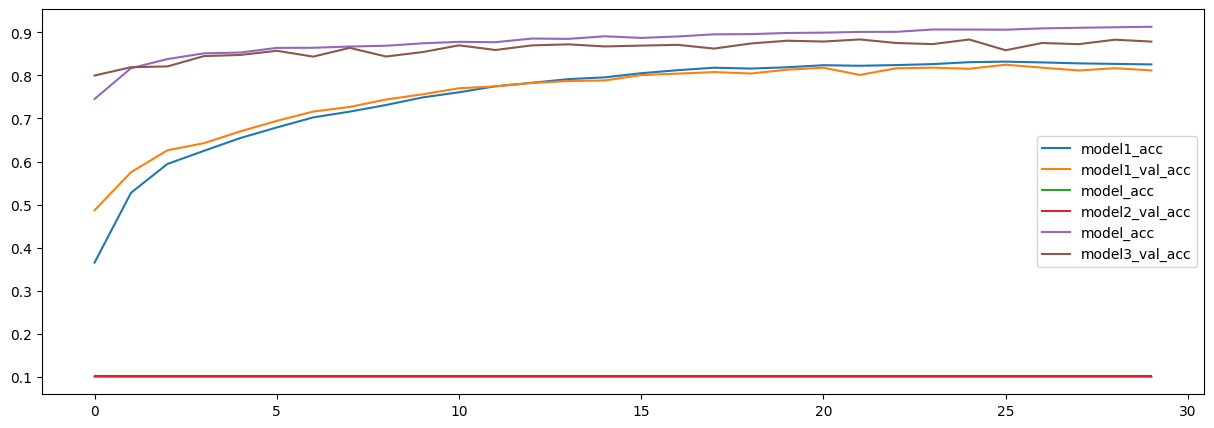

In [ ]:
# 3가지 종류 모델 시각화 진행
plt.figure(figsize=(15,5))

# 1번모델 (sigmoid + sgd)
plt.plot(h1.history['accuracy'], label = 'model1_acc')
plt.plot(h1.history['val_accuracy'], label='model1_val_acc')

# 2번모델 (relu + sgd)
plt.plot(h2.history['accuracy'], label = 'model_acc')
plt.plot(h2.history['val_accuracy'], label='model2_val_acc')

# 3번모델 (relu + Adam)
plt.plot(h3.history['accuracy'], label = 'model_acc')
plt.plot(h3.history['val_accuracy'], label='model3_val_acc')

plt.legend()
plt.show()

### 시각화 결과
- 3개의 모델을 비교했더니 acti:relu/opti:Adam을 사용한 모델이 성능이 가장 좋음

### 얼리스탑핑
- 조기 학습 중단
- 모델을 학습함에 있어서 성능이 더이상 오르지 않은 구간이 있을 때 계속 학습을 진행 시 자원 및 시간낭비가 이루어짐
- 따라서 더이상 성능이 올라가지 않는다고 판단이 되면 내가 설정한 epoch를 전부 학습하는 것이 아닌 중간에 학습을 중지하는 방법
- 과대적합을 어느정도 방지할 수 있고 시간과 자원의 낭비를 줄일 수 있음

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import os

In [ ]:
# 모델 저장
# 베스트 모델을 저장할 폴더
model_dir = '/content/drive/MyDrive/딥러닝/model/'

# 만약에 폴더가 없으면 만들어라
if not os.path.exists(model_dir):
  os.mkdir(model_dir)

# 베스트 모델 파일명 설정
# {epoch:03d} -> epoch 값을 가져와서 정수형 3자리로 표시하겠다
#           만약 3자리보다 적을 경우는 왼쪽부분을 0으로 표시
#            30 -> 030
# {val_accuracy:.2f} -> val_accuracy값을 가져와서 소수점 2째자리까지 표시하기
# 파일명 형태 -> ./model/fashin_030_88.44_86.05.hdf5
model_path = model_dir + 'fasion_{epoch:03d}_{val_accuracy:.2f}.keras'

# ModelCheckPoint 설정
checkpoint = ModelCheckpoint(filepath=model_path, # 체크포인트 된 모델을 저장하는 경로
                             monitor='val_accuracy', # 어떤한 값을 기준으로 저장할지를 설정 -> 검증데이터 정확도를 기준
                             save_best_only=True, # monitor값이 가장 최고점이 될 경우에만 모델을 저장
                             verbose=1)

In [ ]:
# 조기 학습 중단 설정
model_earlystop = EarlyStopping(monitor='val_accuracy',
                                # monitor 값 개선이 몇번안에 개선이 될건지 기다려주는 기능
                                patience = 5
                                )
# epoch가 돌아갈 때 5번동안 성능개선이 안되면 멈추기

In [ ]:
# 모델 설계
model4 = get_model('relu', 'adam')
h4 = model4.fit(X_train, y_train_one_hot,
                validation_split = 0.3,
                epochs = 50,
                batch_size = 64,
                callbacks = [checkpoint, model_earlystop]
                # 모델 체크포인트 설정 및 얼리스탑핑 설정하기
                )

Epoch 1/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6650 - loss: 6.7918
Epoch 1: val_accuracy improved from -inf to 0.79344, saving model to /content/drive/MyDrive/딥러닝/model/fasion_001_0.79.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6652 - loss: 6.7847 - val_accuracy: 0.7934 - val_loss: 0.6445
Epoch 2/50
654/657 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8087 - loss: 0.5565
Epoch 2: val_accuracy improved from 0.79344 to 0.82328, saving model to /content/drive/MyDrive/딥러닝/model/fasion_002_0.82.keras
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8088 - loss: 0.5564 - val_accuracy: 0.8233 - val_loss: 0.5577
Epoch 3/50
648/657 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8358 - loss: 0.4710
Epoch 3: val_accuracy did not improve from 0.82328
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8358 - loss: 0.4710 - val_accuracy: 0.8134 - val_loss: 0.5311
Epoch 4/50
652/657 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8505 - loss: 

In [ ]:
# 모델 불러오기
from tensorflow.keras.models import load_model

In [ ]:
best_model = load_model('/content/drive/MyDrive/딥러닝/model/fasion_013_0.87.keras')

In [ ]:
best_model.evaluate(X_test, y_test_one_hot)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8737 - loss: 0.3888


[0.3953540623188019, 0.8675000071525574]

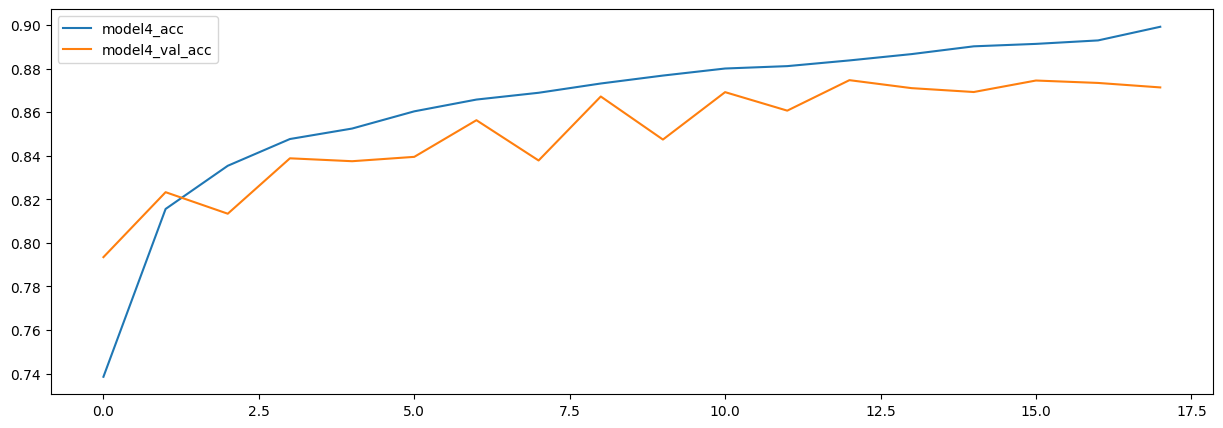

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(h4.history['accuracy'], label = 'model4_acc')
plt.plot(h4.history['val_accuracy'], label = 'model4_val_acc')
plt.legend()
plt.show()

### 과대적합
- 학습데이터에 대해서는 잘 작동하지만 검증을 했을 때 성능이 나오지 않는 경우
- 원인
  - 데이터가 한쪽으로 몰려있는 치중된 데이터일 경우
  - 특성의 수가 너무 많을 경우
  - 학습을 너무 많이 돌린 경우
  - 데이터의 분신값들이 너무 큰 경우 (이상치 존재)
- 해결하기 위해 데이터의 복잡도를 어느정도 줄여주는 작업을 해보자
- Dropout() 사용

In [ ]:
# Dropout 불러오기
from tensorflow.keras.layers import Dropout

# 뼈대 구축
model5 = Sequential()

# 입력층 설계
model5.add(Flatten(input_shape = (28,28)))

# 은닉층 설계
model5.add(Dense(200, activation='relu'))
# 일부분을 사용하지 않도록 설정
model5.add(Dropout(0.2))
model5.add(Dense(100, activation='relu'))
model5.add(Dropout(0.2))
model5.add(Dense(50, activation='relu'))
model5.add(Dropout(0.2))

# 출력층 설계
model5.add(Dense(10,activation = 'softmax'))

model5.compile(loss = 'categorical_crossentropy',
               optimizer = 'adam',
               metrics = ['accuracy'])

In [ ]:
h5 = model5.fit(X_train, y_train_one_hot,
                validation_split = 0.3,
                epochs = 50,
                batch_size = 64,
                callbacks = [checkpoint, model_earlystop]
                )

Epoch 1/50
657/657 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4239 - loss: 11.0226
Epoch 1: val_accuracy did not improve from 0.87472
657/657 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.4240 - loss: 11.0116 - val_accuracy: 0.7326 - val_loss: 0.7622
Epoch 2/50
646/657 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6536 - loss: 0.9910
Epoch 2: val_accuracy did not improve from 0.87472
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6539 - loss: 0.9900 - val_accuracy: 0.7681 - val_loss: 0.6284
Epoch 3/50
654/657 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7135 - loss: 0.7909
Epoch 3: val_accuracy did not improve from 0.87472
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7135 - loss: 0.7908 - val_accuracy: 0.7830 - val_loss: 0.5820
Epoch 4/50
652/657 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7292 - loss: 0.7296
Epoch 4: val_accuracy did not improve from 0.87472
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7293 - loss: 0.7294 - val_accuracy: 0.7965 -

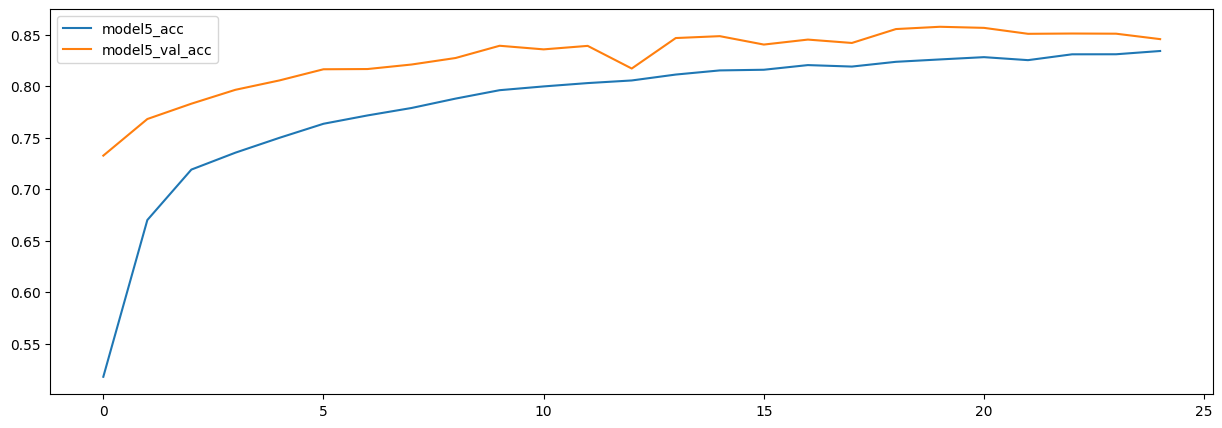

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(h5.history['accuracy'], label = 'model5_acc')
plt.plot(h5.history['val_accuracy'], label = 'model5_val_acc')
plt.legend()
plt.show()